In [5]:
import numpy as np
import pandas as pd
import utils
import matplotlib.pyplot as plt

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
titles = utils.load_items()
M = utils.build_user_item(train)
print('Matrix', M.shape)

Matrix (610, 2000)


In [2]:
pop = utils.PopularityBaseline().fit(M)
cf = utils.ItemBasedCF().fit(M)
svd = utils.SVDRecommender().fit(M, n_components=20)

print('Fitted: Popularity, Item-CF, SVD(20 Factors)',)

Fitted: Popularity, Item-CF, SVD(20 Factors)


In [3]:
rmse = {name: round(utils.rmse_on_test(m, test),4) for name,m in [('Popularity', pop), ('Item-CF', cf),('SVD', svd)]}
rmse_df = pd.Series(rmse, name='RMSE').to_frame()
rmse_df

,RMSE
Popularity,0.9381
Item-CF,0.8298
SVD,0.8918


In [4]:
rows=[]
for name,m in [('Popularity', pop), ('Item-CF', cf),('SVD', svd)]:
    r = utils.precision_recall_at_k(m, M, test, k=10, rel_threshold=4.0)
    rows.append({'model':name, **{kk:r[kk] for kk in ['precision@k', 'recall@k', 'n_users_evaluated']}})
rank_df = pd.DataFrame(rows)
rank_df

,model,precision@k,recall@k,n_users_evaluated
0,Popularity,0.0146,0.0119,591
1,Item-CF,0.0262,0.0107,591
2,SVD,0.1293,0.1200,591


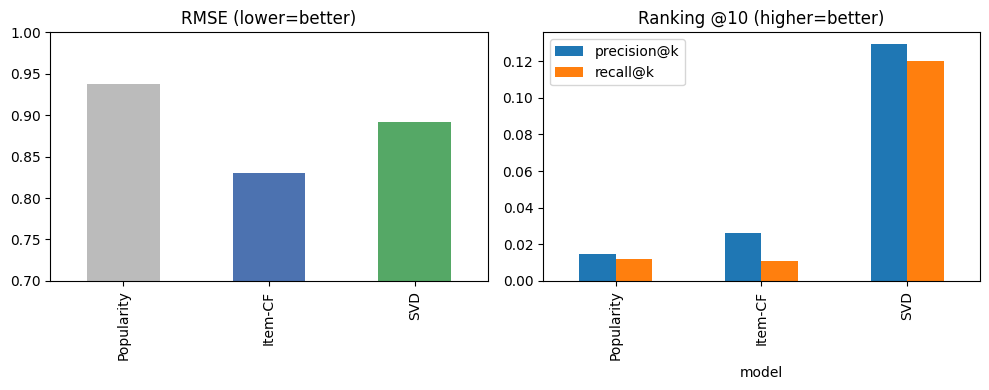

In [6]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
rmse_df['RMSE'].plot(kind='bar', ax=ax[0], color=['#bbb', '#4c72b0', '#55a866'])
ax[0].set_title('RMSE (lower=better)')
ax[0].set_ylim(0.7, 1.0)

rank_df.set_index('model')[['precision@k', 'recall@k']].plot(kind='bar', ax=ax[1])
ax[1].set_title('Ranking @10 (higher=better)')

plt.tight_layout()
plt.show()

In [8]:
#Top-10 unseen movies for one user from the best ranking model (SVD).

uid = M.index[1]
print('Recommendations for user', uid, '\n')
utils.recommend(svd, M, uid, items_lookup=titles, n=10)

Recommendations for user 2 



,item,title,score
0,1196,Star Wars: Episode V - The Empire Strikes Back...,4.023
1,6874,Kill Bill: Vol. 1 (2003),4.021
2,1198,Raiders of the Lost Ark (Indiana Jones and the...,4.021
3,1136,Monty Python and the Holy Grail (1975),4.020
4,7153,"Lord of the Rings: The Return of the King, The...",4.020
5,2683,Austin Powers: The Spy Who Shagged Me (1999),4.019
6,3578,Gladiator (2000),4.018
7,2115,Indiana Jones and the Temple of Doom (1984),4.018
8,924,2001: A Space Odyssey (1968),4.017
9,1356,Star Trek: First Contact (1996),4.016
